<a href="https://colab.research.google.com/github/prit0899/employeePrediction/blob/main/phone_troubleshooting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/phone_troubleshooting.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,question_id,title,question,answer,tags,question_score,answer_score
0,2,"I installed another SMS application, now I get...","I installed another SMS application, now I get...",You can turn off notification in your stock Me...,notifications|2.2-froyo|handcent-sms|sms,11,19
1,8,How do I send a contact via SMS?,How do I send a contact via SMS? I would like ...,For users with Ice Cream Sandwich: Using the s...,contacts|sms,11,4
2,11,How do I stop from getting notified twice when...,How do I stop from getting notified twice when...,"From Google Voice settings (on the web, not th...",notifications|google-voice|sms,7,5
3,16,How do I keep my wi-fi on in sleep mode,How do I keep my wi-fi on in sleep mode When I...,Go to: Settings > Wireless & networks > Wi-Fi ...,wi-fi|standby,18,17
4,31,How do I change the home screen's Email icon t...,How do I change the home screen's Email icon t...,"click ""applications"", click menu button, click...",samsung-galaxy-s|home-screen|att|email|gmail,9,14


In [2]:
# Display basic information about the DataFrame
df.info()

# Display the shape of the DataFrame
print(f"\nDataFrame shape: {df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9684 entries, 0 to 9683
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   question_id     9684 non-null   int64 
 1   title           9684 non-null   object
 2   question        9684 non-null   object
 3   answer          9684 non-null   object
 4   tags            9684 non-null   object
 5   question_score  9684 non-null   int64 
 6   answer_score    9684 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 529.7+ KB

DataFrame shape: (9684, 7)


In [3]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
question_id,0
title,0
question,0
answer,0
tags,0
question_score,0
answer_score,0


In [4]:
# The 'tags' column contains multiple tags separated by '|'
# Let's split the tags and explode them to get individual tags
all_tags = df['tags'].str.split('|').explode()

# Get the value counts of each tag
tag_counts = all_tags.value_counts()

# Display the top 20 most frequent tags
print("\nTop 20 most frequent tags:")
display(tag_counts.head(20))


Top 20 most frequent tags:


,count
tags,
applications,1656
google-play-store,1304
wi-fi,970
contacts,630
notifications,607
settings,601
sms,580
battery,456
sync,450


In [5]:
# Combine relevant text columns into a single feature for classification
df['text'] = df['title'] + " " + df['question'] + " " + df['answer']

# Display the first few rows with the new 'text' column
display(df[['text', 'tags']].head())

,text,tags
0,"I installed another SMS application, now I get...",notifications|2.2-froyo|handcent-sms|sms
1,How do I send a contact via SMS? How do I send...,contacts|sms
2,How do I stop from getting notified twice when...,notifications|google-voice|sms
3,How do I keep my wi-fi on in sleep mode How do...,wi-fi|standby
4,How do I change the home screen's Email icon t...,samsung-galaxy-s|home-screen|att|email|gmail


In [6]:
# Convert the 'tags' string into a list of tags for each entry
df['tag_list'] = df['tags'].apply(lambda x: x.split('|'))

# Display the first few rows with the new 'tag_list' column
display(df[['text', 'tag_list']].head())

,text,tag_list
0,"I installed another SMS application, now I get...","[notifications, 2.2-froyo, handcent-sms, sms]"
1,How do I send a contact via SMS? How do I send...,"[contacts, sms]"
2,How do I stop from getting notified twice when...,"[notifications, google-voice, sms]"
3,How do I keep my wi-fi on in sleep mode How do...,"[wi-fi, standby]"
4,How do I change the home screen's Email icon t...,"[samsung-galaxy-s, home-screen, att, email, gm..."


In [7]:
from sklearn.preprocessing import MultiLabelBinarizer

# Initialize MultiLabelBinarizer
mlb = MultiLabelBinarizer()

# Fit and transform the tag_list to create multi-hot encoded labels
# This will result in a sparse matrix or a dense array
y = mlb.fit_transform(df['tag_list'])

# Create a DataFrame for better readability (optional, but good for inspection)
y_df = pd.DataFrame(y, columns=mlb.classes_)

print(f"Shape of the multi-hot encoded labels: {y.shape}")
print("\nFirst 5 rows of the multi-hot encoded labels (sample of columns):")
display(y_df.head())

Shape of the multi-hot encoded labels: (9684, 1102)

First 5 rows of the multi-hot encoded labels (sample of columns):


,1.5-cupcake,1.6-donut,2-step-verification,2.1-eclair,2.2-froyo,2.3-gingerbread,2fa,2g,3.0-honeycomb,3.1-honeycomb,...,xposed-framework,xprivacy,yahoo-mail,youtube,zip,zoom-cloud-meetings,zooming,zte,zte-blade,zte-racer
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
# You might want to adjust parameters like max_features, min_df, max_df, ngram_range based on your data
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 for demonstration

# Fit and transform the 'text' column
X = tfidf_vectorizer.fit_transform(df['text'])

print(f"Shape of the TF-IDF vectorized text: {X.shape}")

Shape of the TF-IDF vectorized text: (9684, 5000)


In [9]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# We'll use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (7747, 5000)
Shape of X_test: (1937, 5000)
Shape of y_train: (7747, 1102)
Shape of y_test: (1937, 1102)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# Define the base classifier (Logistic Regression with balanced class weights)
classifier = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')

# Wrap the classifier in OneVsRestClassifier for multi-label classification
multi_label_classifier = OneVsRestClassifier(classifier)

# Train the classifier
print("Training the multi-label classifier...")
multi_label_classifier.fit(X_train, y_train)
print("Training complete.")

Training the multi-label classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 46 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 51 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 101 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 105 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 120 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 138 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 152 is present in all training 

Training complete.


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set with the re-trained model
y_pred_balanced = multi_label_classifier.predict(X_test)

# Evaluate the model using appropriate multi-label metrics
# Exact match accuracy
exact_accuracy_balanced = accuracy_score(y_test, y_pred_balanced)

# Micro averaging
precision_micro_balanced = precision_score(y_test, y_pred_balanced, average='micro', zero_division=0)
recall_micro_balanced = recall_score(y_test, y_pred_balanced, average='micro', zero_division=0)
f1_micro_balanced = f1_score(y_test, y_pred_balanced, average='micro', zero_division=0)

# Macro averaging
precision_macro_balanced = precision_score(y_test, y_pred_balanced, average='macro', zero_division=0)
recall_macro_balanced = recall_score(y_test, y_pred_balanced, average='macro', zero_division=0)
f1_macro_balanced = f1_score(y_test, y_pred_balanced, average='macro', zero_division=0)

print("--- Evaluation with class_weight='balanced' ---")
print(f"Exact Match Accuracy: {exact_accuracy_balanced:.4f}")
print(f"Micro Precision: {precision_micro_balanced:.4f}")
print(f"Micro Recall: {recall_micro_balanced:.4f}")
print(f"Micro F1-score: {f1_micro_balanced:.4f}")
print(f"Macro Precision: {precision_macro_balanced:.4f}")
print(f"Macro Recall: {recall_macro_balanced:.4f}")
print(f"Macro F1-score: {f1_macro_balanced:.4f}")

--- Evaluation with class_weight='balanced' ---
Exact Match Accuracy: 0.0372
Micro Precision: 0.3906
Micro Recall: 0.6249
Micro F1-score: 0.4807
Macro Precision: 0.1491
Macro Recall: 0.2060
Macro F1-score: 0.1566


### Exploring Multinomial Naive Bayes

`Multinomial Naive Bayes` is a probabilistic classifier suitable for classification with discrete features (e.g., word counts for text classification). It is often a good baseline due to its simplicity and efficiency.

In [14]:
from sklearn.naive_bayes import MultinomialNB

# Define the base classifier (Multinomial Naive Bayes)
# MultinomialNB does not directly support class_weight='balanced'
# For multi-label, we again wrap it in OneVsRestClassifier
classifier_mnb = MultinomialNB()
multi_label_classifier_mnb = OneVsRestClassifier(classifier_mnb)

# Train the classifier
print("Training the Multinomial Naive Bayes multi-label classifier...")
multi_label_classifier_mnb.fit(X_train, y_train)
print("Training complete for Multinomial Naive Bayes.")

Training the Multinomial Naive Bayes multi-label classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 46 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 51 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 101 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 105 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 120 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 138 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 152 is present in all training 

Training complete for Multinomial Naive Bayes.


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set with the Multinomial Naive Bayes model
y_pred_mnb = multi_label_classifier_mnb.predict(X_test)

# Evaluate the model using appropriate multi-label metrics
exact_accuracy_mnb = accuracy_score(y_test, y_pred_mnb)

precision_micro_mnb = precision_score(y_test, y_pred_mnb, average='micro', zero_division=0)
recall_micro_mnb = recall_score(y_test, y_pred_mnb, average='micro', zero_division=0)
f1_micro_mnb = f1_score(y_test, y_pred_mnb, average='micro', zero_division=0)

precision_macro_mnb = precision_score(y_test, y_pred_mnb, average='macro', zero_division=0)
recall_macro_mnb = recall_score(y_test, y_pred_mnb, average='macro', zero_division=0)
f1_macro_mnb = f1_score(y_test, y_pred_mnb, average='macro', zero_division=0)

print("--- Evaluation with Multinomial Naive Bayes ---")
print(f"Exact Match Accuracy: {exact_accuracy_mnb:.4f}")
print(f"Micro Precision: {precision_micro_mnb:.4f}")
print(f"Micro Recall: {recall_micro_mnb:.4f}")
print(f"Micro F1-score: {f1_micro_mnb:.4f}")
print(f"Macro Precision: {precision_macro_mnb:.4f}")
print(f"Macro Recall: {recall_macro_mnb:.4f}")
print(f"Macro F1-score: {f1_macro_mnb:.4f}")

--- Evaluation with Multinomial Naive Bayes ---
Exact Match Accuracy: 0.0212
Micro Precision: 0.5020
Micro Recall: 0.0497
Micro F1-score: 0.0905
Macro Precision: 0.0070
Macro Recall: 0.0016
Macro F1-score: 0.0024


### Exploring Support Vector Classifier (SVC)

`Support Vector Classifiers` are effective in high-dimensional spaces and are often used for text classification. We will train an SVC model with `class_weight='balanced'` to handle the dataset's inherent class imbalance.

In [16]:
from sklearn.svm import SVC

# Define the base classifier (SVC with balanced class weights)
# For multi-label, we again wrap it in OneVsRestClassifier
classifier_svc = SVC(kernel='linear', probability=True, random_state=42, class_weight='balanced')
multi_label_classifier_svc = OneVsRestClassifier(classifier_svc)

# Train the classifier
print("Training the Support Vector Classifier multi-label classifier...")
# SVC training can be computationally intensive, especially with many features/samples.
# This might take a while.
multi_label_classifier_svc.fit(X_train, y_train)
print("Training complete for Support Vector Classifier.")

Training the Support Vector Classifier multi-label classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 46 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 51 is present in all training examples.
  warnings.warn(


KeyboardInterrupt: 

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set with the SVC model
y_pred_svc = multi_label_classifier_svc.predict(X_test)

# Evaluate the model using appropriate multi-label metrics
exact_accuracy_svc = accuracy_score(y_test, y_pred_svc)

precision_micro_svc = precision_score(y_test, y_pred_svc, average='micro', zero_division=0)
recall_micro_svc = recall_score(y_test, y_pred_svc, average='micro', zero_division=0)
f1_micro_svc = f1_score(y_test, y_pred_svc, average='micro', zero_division=0)

precision_macro_svc = precision_score(y_test, y_pred_svc, average='macro', zero_division=0)
recall_macro_svc = recall_score(y_test, y_pred_svc, average='macro', zero_division=0)
f1_macro_svc = f1_score(y_test, y_pred_svc, average='macro', zero_division=0)

print("--- Evaluation with Support Vector Classifier ---")
print(f"Exact Match Accuracy: {exact_accuracy_svc:.4f}")
print(f"Micro Precision: {precision_micro_svc:.4f}")
print(f"Micro Recall: {recall_micro_svc:.4f}")
print(f"Micro F1-score: {f1_micro_svc:.4f}")
print(f"Macro Precision: {precision_macro_svc:.4f}")
print(f"Macro Recall: {recall_macro_svc:.4f}")
print(f"Macro F1-score: {f1_macro_svc:.4f}")

AttributeError: 'OneVsRestClassifier' object has no attribute 'estimators_'

### Adjusting Prediction Thresholds for Logistic Regression

We'll use the `predict_proba` method of the `OneVsRestClassifier` to get the probability of each tag being present for each test sample. Then, we can apply different thresholds to these probabilities to see how the evaluation metrics change.

In [21]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from google.colab import files
import joblib # Import joblib for saving the model

# Get probability predictions from the Logistic Regression model
# The predict_proba method returns probabilities for each class for each sample.
# For OneVsRestClassifier, it returns a matrix of shape (n_samples, n_classes).
print("Getting probability predictions...")
y_proba = multi_label_classifier.predict_proba(X_test)
print("Probability predictions obtained.")

# Define a range of thresholds to explore
thresholds = np.arange(0.05, 0.96, 0.05) # From 0.05 to 0.95 with steps of 0.05

results = []

print("Evaluating performance across different thresholds...")
for threshold in thresholds:
    # Convert probabilities to binary predictions based on the current threshold
    y_pred_thresholded = (y_proba >= threshold).astype(int)

    # Calculate evaluation metrics
    exact_accuracy = accuracy_score(y_test, y_pred_thresholded)
    precision_micro = precision_score(y_test, y_pred_thresholded, average='micro', zero_division=0)
    recall_micro = recall_score(y_test, y_pred_thresholded, average='micro', zero_division=0)
    f1_micro = f1_score(y_test, y_pred_thresholded, average='micro', zero_division=0)
    precision_macro = precision_score(y_test, y_pred_thresholded, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred_thresholded, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred_thresholded, average='macro', zero_division=0)

    results.append({
        'threshold': threshold,
        'exact_accuracy': exact_accuracy,
        'micro_precision': precision_micro,
        'micro_recall': recall_micro,
        'micro_f1': f1_micro,
        'macro_precision': precision_macro,
        'macro_recall': recall_macro,
        'macro_f1': f1_macro,
    })

# Convert results to a DataFrame for easy viewing
results_df = pd.DataFrame(results)
display(results_df)
print("Threshold evaluation complete.")

# Save the trained model before downloading
joblib.dump(multi_label_classifier, 'model.pkl')
files.download("model.pkl")

Getting probability predictions...
Probability predictions obtained.
Evaluating performance across different thresholds...


,threshold,exact_accuracy,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1
0,0.05,0.000000,0.039135,0.912556,0.075051,0.036355,0.415796,0.057769
1,0.10,0.000000,0.081643,0.863610,0.149183,0.070452,0.365838,0.100522
2,0.15,0.000000,0.123050,0.820855,0.214017,0.091559,0.329838,0.121982
3,0.20,0.000516,0.163735,0.785258,0.270970,0.106112,0.301292,0.135367
4,0.25,0.001549,0.204318,0.757980,0.321873,0.115774,0.285071,0.145178
5,0.30,0.004646,0.244367,0.730122,0.366177,0.126419,0.264177,0.151414
6,0.35,0.010325,0.281844,0.702457,0.402282,0.131811,0.248341,0.153453
7,0.40,0.015488,0.318485,0.673631,0.432493,0.137752,0.231371,0.154876
8,0.45,0.026846,0.352985,0.647514,0.456897,0.141832,0.217436,0.155354
9,0.50,0.037171,0.390616,0.624879,0.480726,0.149126,0.205995,0.156571


Threshold evaluation complete.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The table above shows the performance of the Logistic Regression model with `class_weight='balanced'` at various prediction thresholds. We can now visualize these metrics to better understand the trade-offs.

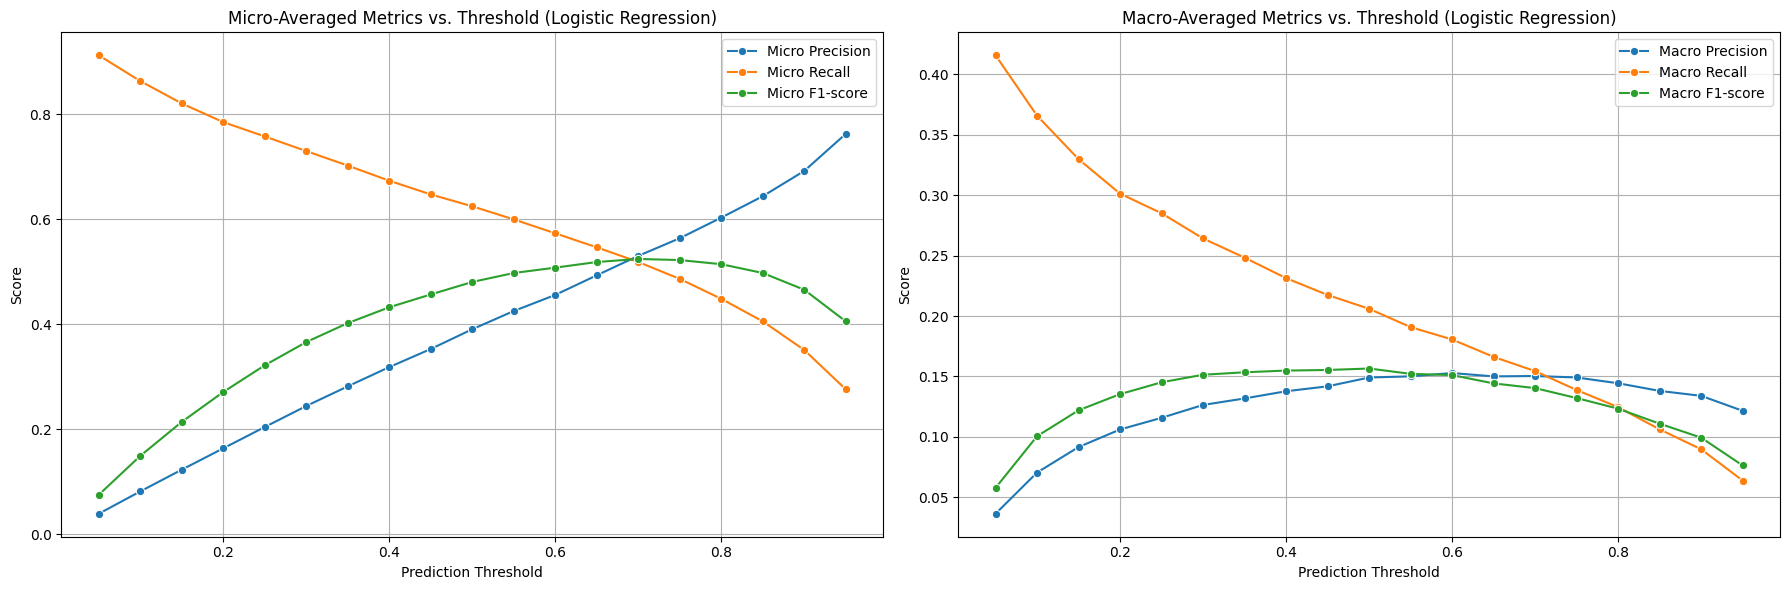

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

sns.lineplot(ax=axes[0], x='threshold', y='micro_precision', data=results_df, label='Micro Precision', marker='o')
sns.lineplot(ax=axes[0], x='threshold', y='micro_recall', data=results_df, label='Micro Recall', marker='o')
sns.lineplot(ax=axes[0], x='threshold', y='micro_f1', data=results_df, label='Micro F1-score', marker='o')
axes[0].set_title('Micro-Averaged Metrics vs. Threshold (Logistic Regression)')
axes[0].set_xlabel('Prediction Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True)

sns.lineplot(ax=axes[1], x='threshold', y='macro_precision', data=results_df, label='Macro Precision', marker='o')
sns.lineplot(ax=axes[1], x='threshold', y='macro_recall', data=results_df, label='Macro Recall', marker='o')
sns.lineplot(ax=axes[1], x='threshold', y='macro_f1', data=results_df, label='Macro F1-score', marker='o')
axes[1].set_title('Macro-Averaged Metrics vs. Threshold (Logistic Regression)')
axes[1].set_xlabel('Prediction Threshold')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
y_pred = multi_label_classifier.predict(X_test)

# Evaluate the model using appropriate multi-label metrics
# Exact match accuracy
exact_accuracy = accuracy_score(y_test, y_pred)

# Other metrics (macro or micro averaging are common for multi-label)
# Using 'micro' averaging as it aggregates the contributions of all classes to compute the average metric.
# It's suitable for imbalanced datasets and when you want to give more weight to frequent classes.
precision_micro = precision_score(y_test, y_pred, average='micro', zero_division=0)
recall_micro = recall_score(y_test, y_pred, average='micro', zero_division=0)
f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)

# Using 'macro' averaging as it computes the metric independently for each class, and then averages them.
# It treats all classes equally, regardless of their support, and can highlight performance issues in rare classes.
precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"Exact Match Accuracy: {exact_accuracy:.4f}")
print(f"Micro Precision: {precision_micro:.4f}")
print(f"Micro Recall: {recall_micro:.4f}")
print(f"Micro F1-score: {f1_micro:.4f}")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")
print(f"Macro F1-score: {f1_macro:.4f}")

Exact Match Accuracy: 0.0898
Micro Precision: 0.8716
Micro Recall: 0.2260
Micro F1-score: 0.3589
Macro Precision: 0.0373
Macro Recall: 0.0131
Macro F1-score: 0.0174
